In [104]:
#Importing libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from TextPreprocessor import TextPreprocessor

#from src.TextPreprocessor import TextPreprocessor

In [105]:
dataset = pd.read_csv("../data/imdb_dataset.csv")
preprocessor = TextPreprocessor(True, True, True)
dataset['cleaned_review'] = preprocessor.process(dataset['review'])


In [96]:
print(dataset.head())
print(dataset.info())
print(dataset['sentiment'].value_counts())

                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      cleaned_review  
0  one reviewers mentioned watching 1 oz episode ...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake thinks zombie...  
4  petter mattei love time money visually stunnin...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review          50000 non-null  object
 1   sentiment       50000 non-nu

In [97]:
#adds a new coloumn to dataset that contains the length of the review
dataset['review_length'] = dataset['cleaned_review'].apply(len)

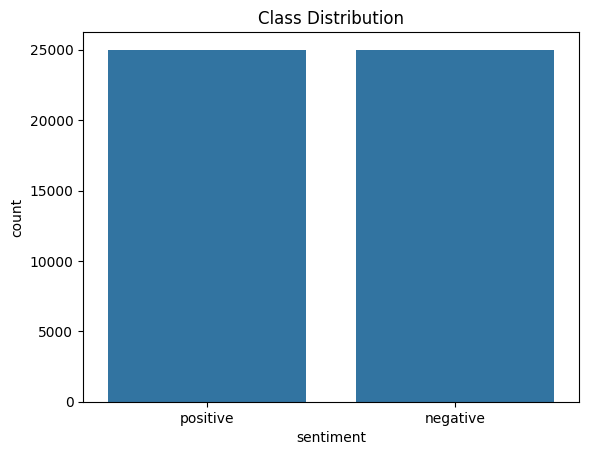

In [98]:
#graph that shows the number of positive reviews with the amount of negative reviews
#since the dataset is balanced, the two bars should be equal
sns.countplot(x='sentiment', data=dataset)
plt.title("Class Distribution")
plt.show()

Text(0.5, 1.0, 'Top Words in Positive Reviews')

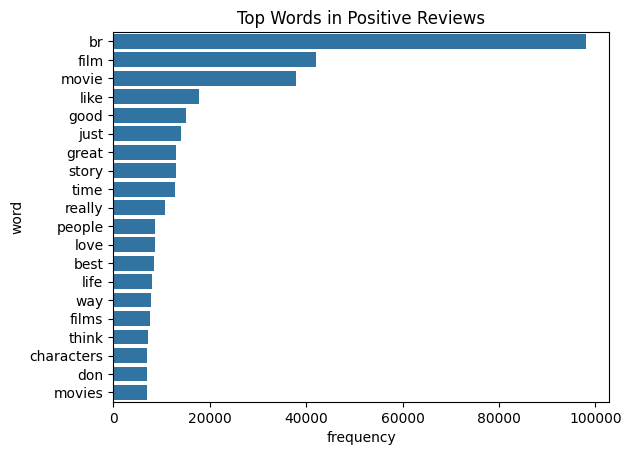

In [ ]:
#here were using a count vectorizer to show the most frequent words in positive and negative reviews

vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X_counts = vectorizer.fit_transform(dataset[dataset['sentiment'] == 'positive']['cleaned_review'])

word_freq = pd.DataFrame({'word': vectorizer.get_feature_names_out(), 'frequency': X_counts.sum(axis=0).A1})
top_words = word_freq.sort_values(by='frequency', ascending=False).head(20)

sns.barplot(x='frequency', y='word', data=top_words)
plt.title('Top Words in Positive Reviews')

Text(0.5, 1.0, 'Top Words in Negative Reviews')

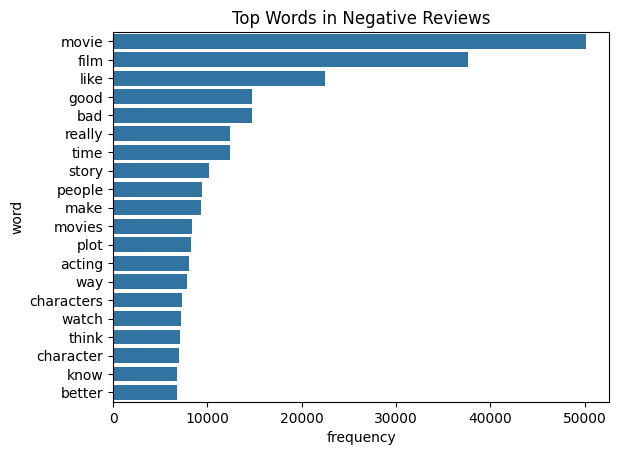

In [100]:
#copy and paste the above code to show the most frequent words in negative reviews
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X_counts = vectorizer.fit_transform(dataset[dataset['sentiment'] == 'negative']['cleaned_review'])

word_freq = pd.DataFrame({'word': vectorizer.get_feature_names_out(), 'frequency': X_counts.sum(axis=0).A1})
top_words = word_freq.sort_values(by='frequency', ascending=False).head(20)

sns.barplot(x='frequency', y='word', data=top_words)
plt.title('Top Words in Negative Reviews')

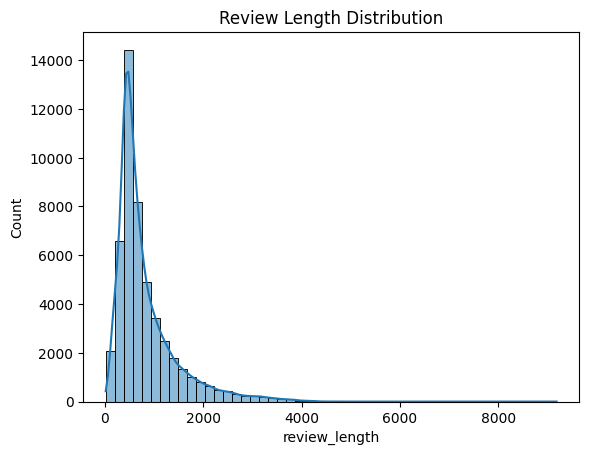

In [101]:
#This part displays a bargraph for the 
sns.histplot(dataset['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.show()

In [102]:
type(dataset)

pandas.core.frame.DataFrame

In [ ]:
# Save the cleaned dataset to a new CSV file
del dataset['review'] #delete the original review column to save space cause i was running into issues pushing to github
dataset.to_csv("../data/imdb_cleaned.csv", index=False)
